In [20]:
#Performing Linear Regression on the dataset
#House Price Prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [21]:
#LOAD DATASET
import pandas as pd

# Define the 14 standard column names for the Boston Housing dataset
column_names = [
    'CRIM',    # Per capita crime rate by town
    'ZN',      # Proportion of residential land zoned for lots over 25,000 sq.ft.
    'INDUS',   # Proportion of non-retail business acres per town
    'CHAS',    # Charles River dummy variable (1 if tract bounds river; 0 otherwise)
    'NOX',     # Nitric oxides concentration (parts per 10 million)
    'RM',      # Average number of rooms per dwelling
    'AGE',     # Proportion of owner-occupied units built prior to 1940
    'DIS',     # Weighted distances to five Boston employment centres
    'RAD',     # Index of accessibility to radial highways
    'TAX',     # Full-value property-tax rate per $10,000
    'PTRATIO', # Pupil-teacher ratio by town
    'B',       # 1000(Bk - 0.63)^2 where Bk is the proportion of Black residents by town
    'LSTAT',   # % lower status of the population
    'MEDV'     # Median value of owner-occupied homes in $1000's (TARGET VARIABLE)
]

# Load space-delimited file without assuming header
df = pd.read_csv(
    r'house Prediction Data Set.csv', 
    sep=r'\s+', 
    header=None, 
    names=column_names
)

# Display clean DataFrame shape and first 5 rows
print("Dataset Shape:", df.shape) # Output should be (506, 14)
display(df.head())

Dataset Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [22]:
#Checking for missing values
df.isnull().sum()
#Using the mean to fill the missing values in the dataset
# Modern & safe way to fill missing numeric values with the mean# Modern & safe way to fill missing numeric values with the mean
df = df.fillna(df.mean(numeric_only=True))
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

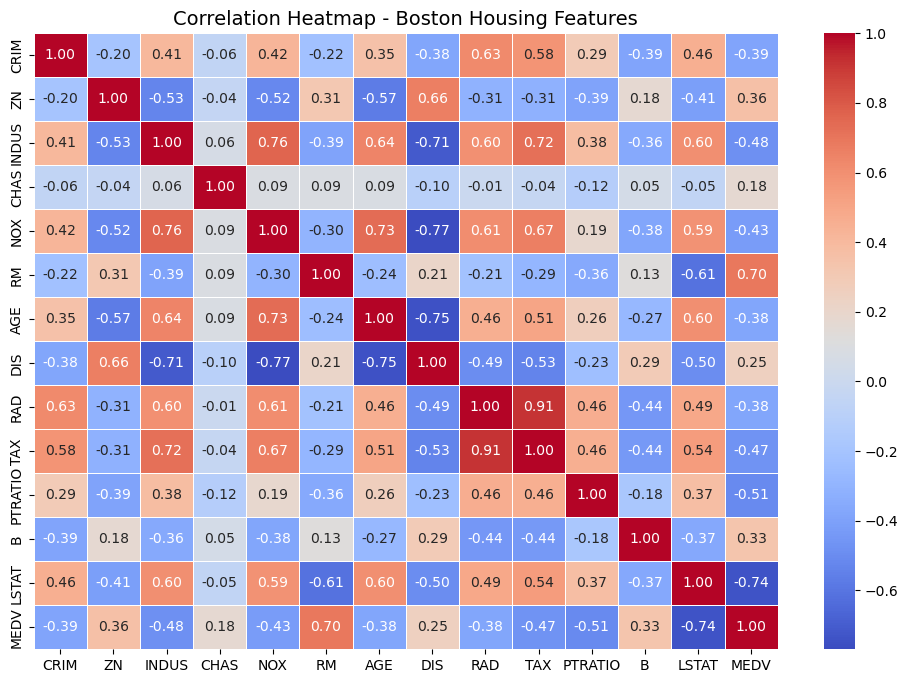

In [23]:
#exploring the correlation between the variables
# Create a correlation matrix of numeric columns
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap - Boston Housing Features', fontsize=14)
plt.show()

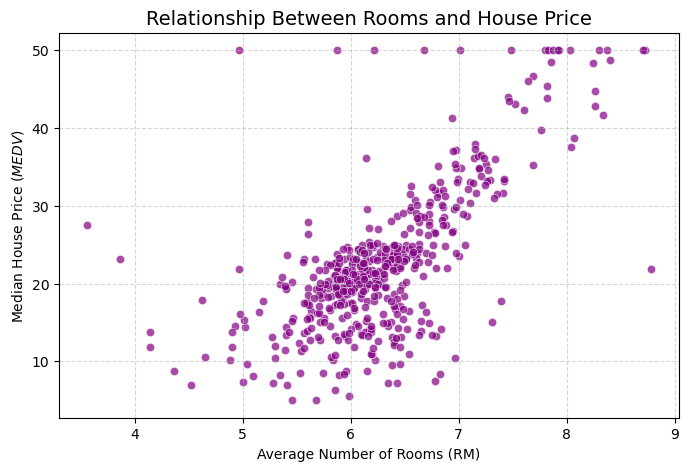

In [24]:

# Plotting Average Rooms (RM) against House Price (MEDV)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='RM', y='MEDV', data=df, color='purple', alpha=0.7)
plt.title('Relationship Between Rooms and House Price', fontsize=14)
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median House Price ($MEDV$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [25]:
# Handle missing values if necessary
df.dropna(inplace=True)

# Split the data into features (X) and target variable (y)
X = df[['RM']]      # Double brackets keep X as a 2D DataFrame (required by scikit-learn)
y = df['MEDV']      # Target variable (1D Series)

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Create a linear regression model instance
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Model training complete! 🎉")

Model training complete! 🎉


In [28]:
# Make predictions on the test dataset
y_predn = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_predn)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# 2. Calculate R-squared Score using model.score()
r2 = model.score(X_test, y_test)
print(f"R-squared Score (R²): {r2:.4f}")

# 3. Optional: Mean Absolute Error (MAE) for dollar-value context
mae = mean_absolute_error(y_test, y_predn)
print(f"Mean Absolute Error (MAE): ${mae * 1000:.2f}")

Mean Squared Error (MSE): 46.1448
R-squared Score (R²): 0.3708
Mean Absolute Error (MAE): $4478.34


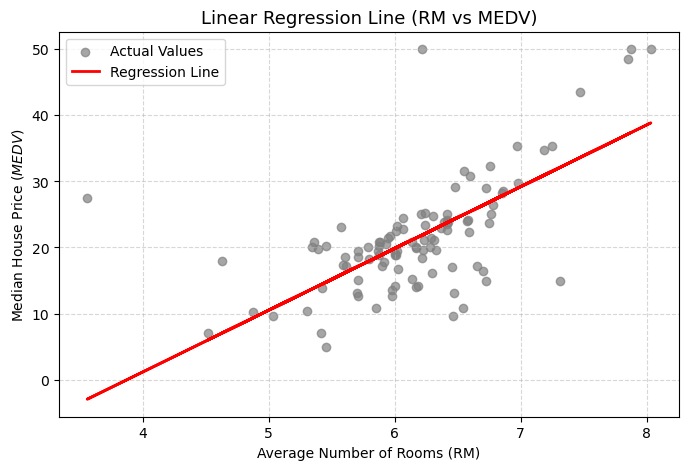

In [31]:
# Plot actual points vs fitted line
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='gray', alpha=0.7, label='Actual Values')
plt.plot(X_test, y_predn, color='red', linewidth=2, label='Regression Line')

plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median House Price ($MEDV$)')
plt.title('Linear Regression Line (RM vs MEDV)', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()